In [1]:
using Colors, ColorSchemes
using CairoMakie
using StatsBase
using FixedPointNumbers
using VideoIO
using Base.Threads
function save_plot(fig, filename::String="plot"; redo::Bool=true, folder::String="Plots", kwargs...)
    # Saves the plot to a file.
    # Arguments: 
    # pl: the plot to be saved
    # filename [String]: the name of the file to be saved (default: "plot")
    # redo [Bool]: if true, the file will be saved even if it already exists (default: true)
    # kwargs: additional keyword arguments to be passed to savefig
    #          - e.g. dpi=300, quality=95, etc.
    # Returns: nothing


    # generate Plots directory if missing 
    # add .png if file ending is missing [does not end in .jpg, .png, .pdf, .svg, .pdf]
    if !isdir(folder)
        mkdir(folder)
    end
    if !endswith(filename, ".jpg") && !endswith(filename, ".png") && !endswith(filename, ".pdf") && !endswith(filename, ".svg")
        filename *= ".png"
    end
    filefolder = joinpath(folder, filename)
    if isfile(filefolder) && !redo
        return
    end
    # save the plot
    save(filefolder, fig; kwargs...)
    return fig
end

x = 0.5
blue2transparent = [RGB{N0f8}(i, i, 1) for i in range(0, stop=1, length=128)]
transparent2red = [RGB{N0f8}(1, 1-i, 1-i) for i in range(0, stop=1, length=128)]
together = vcat(blue2transparent, transparent2red)
custom_scheme = ColorScheme(together)

println("Done")
custom_scheme

Done


In [2]:
# Make a gaussian distribution for g and Delta 
g0 = 150/10^6  # 150Hz
delta_g = g0*0.20
delta0 = 0.0
delta_delta = 0.1 # 100kHz 
sigmas = 3.0
range_vec = [[g0-sigmas*delta_g, g0+sigmas*delta_g], [-delta_delta*sigmas, delta_delta*sigmas]]
N = 10^6

gaussian = (x, mu, sigma) -> exp.(-(x.-mu)^2 ./sigma^2/2)*1 ./sqrt(2*pi*sigma^2)
# sample 10^6 values of sigma and delta 
g_samples = g0 .+ delta_g*randn(N)
delta_samples = delta0 .+ delta_delta*randn(N)
println("Done")

Done


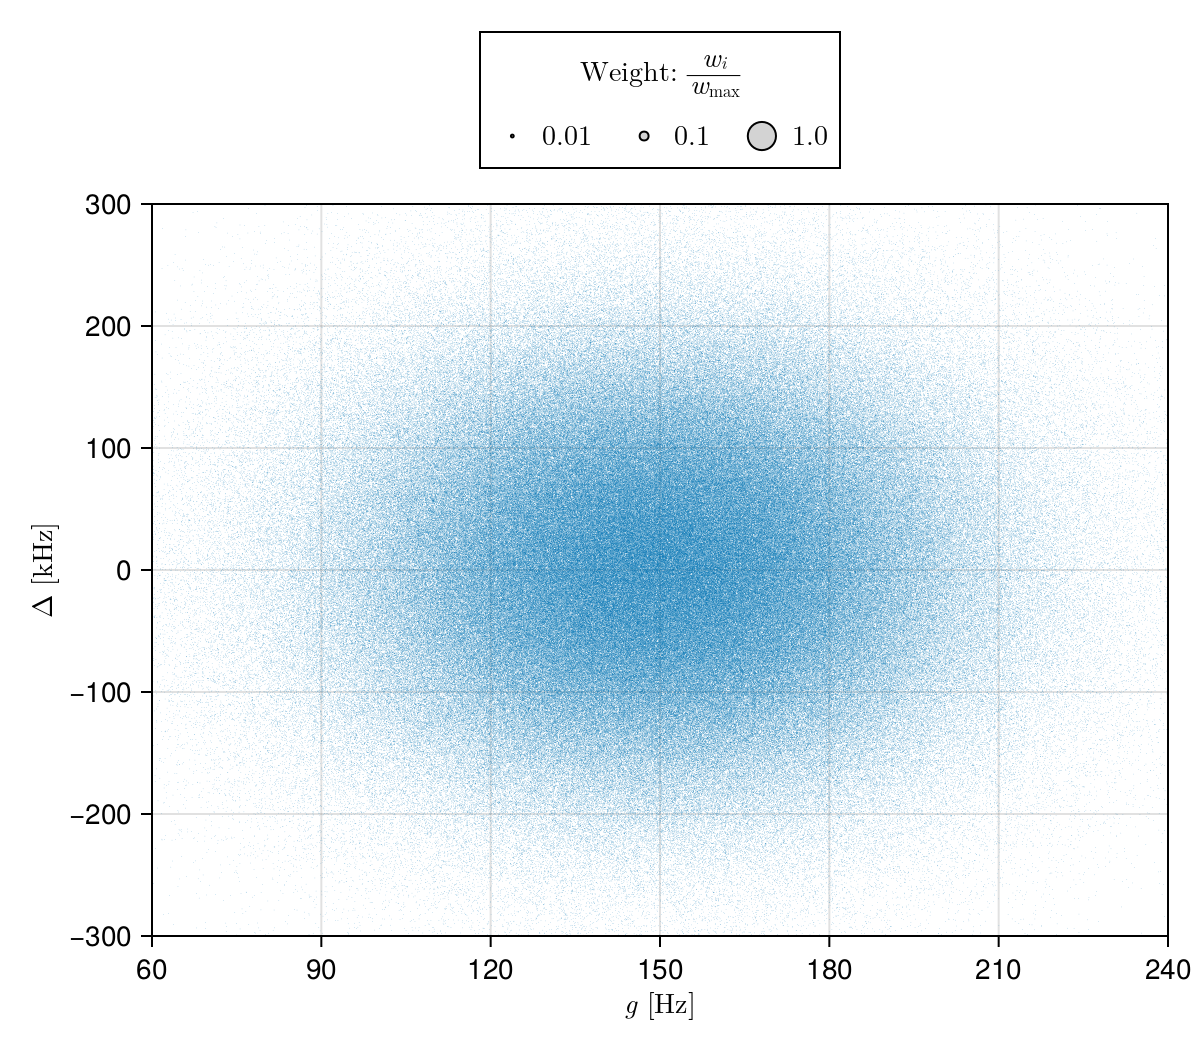

In [20]:
function transform_to_closest_unit(v::Vector{Float64}, base_unit::String="Hz", factor=10^6; dolatex::Bool=false, return_scale::Bool=false)
    new_v::Vector{Float64} = v .* factor # rescale to base unit 
    # find unit of maximum exponent of abs(new_v)
    max_exp::Int = floor(Int, log10(maximum(abs.(new_v))))
    # closest multiple of 3 (floor)
    unit_strs::Vector{String} = ["n", "μ", "m", "", "k", "M", "G", "T"]
    if dolatex
        unit_strs = ["n", L"\mu", "m", "", "k", "M", "G", "T"]
    end
    exp_ind::Int = 0
    if max_exp > 0
        exp_ind = max(1, min(8, max_exp ÷ 3 + 4))  # 1 is n, 4 is "", 8 is T
    else
        exp_ind = floor(Int, max_exp / 3) + 4
    end
    new_factor::Float64 = 10.0^(3 * (exp_ind - 4))
    new_unit::String = unit_strs[exp_ind] * base_unit
    new_v = new_v ./ new_factor
    if !return_scale
        return new_v, new_unit
    else
        return new_v, new_unit, factor / new_factor
    end
end
# Version with complex v -> use norm 
function transform_to_closest_unit(v::Vector{ComplexF64}, base_unit::String="Hz", factor=10^6; dolatex::Bool=false, return_scale::Bool=false)
    return transform_to_closest_unit(norm.(v), base_unit, factor; dolatex=dolatex, return_scale=return_scale)
end

function transform_to_closest_unit(v::Vector{Float64}, w::Vector{Float64}, base_unit::String="Hz", factor=10^6; dolatex::Bool=false)
    # same but for two vectors v and w
    if base_unit == "Hz"
        factor /= 2 * pi
    end
    new_v::Vector{Float64} = v .* factor # rescale to base unit 
    new_w::Vector{Float64} = w .* factor # rescale to base unit
    # find unit of maximum exponent of abs(new_v)
    max_val = max(maximum(abs.(new_v)), maximum(abs.(new_w)))
    max_exp::Int = floor(Int, log10(max_val))
    # closest multiple of 3 (floor)
    unit_strs::Vector{String} = ["n", "μ", "m", "", "k", "M", "G", "T"]
    if dolatex
        unit_strs = ["n", L"\mu", "m", "", "k", "M", "G", "T"]
    end
    exp_ind::Int = 0
    if max_exp > 0
        exp_ind = max(1, min(8, max_exp ÷ 3 + 4))  # 1 is n, 4 is "", 8 is T
    else
        exp_ind = floor(Int, max_exp / 3) + 4
    end
    new_factor::Float64 = 10.0^(3 * (exp_ind - 4))
    new_unit::String = unit_strs[exp_ind] * base_unit
    new_v = new_v ./ new_factor
    new_w = new_w ./ new_factor
    return new_v, new_w, new_unit
end
# Version with complex v -> use norm, and w -> use norm
function transform_to_closest_unit(v::Vector{ComplexF64}, w::Vector{ComplexF64}, base_unit::String="Hz", factor=10^6; dolatex::Bool=false)
    return transform_to_closest_unit(norm.(v), norm.(w), base_unit, factor; dolatex=dolatex)
end

function make_scatter_weight_legend_small(f, markersizes, markerstr; strokewidth=1.0)
    group_size = [MarkerElement(marker=:circle, color=:lightgray, markersize=ms, strokewidth=strokewidth) for ms in markersizes]
    legend = Legend(f,
        [group_size],
        [markerstr],
        [L"Weight: $\frac{w_i}{w_\text{max}}$"], tellheight=true)
    legend.orientation = :horizontal
    legend.tellheight = true
    legend.tellwidth = false
    return legend
end

function plot_weighted_locations_2D(g_samples::Vector{Float64}, delta_samples::Vector{Float64}, range_vec::Vector{Vector{Float64}}, var_strs::Vector{String}; ms=20, ms2=3, base_unit::String="Hz", factor=10^6, xlabel::String="", ylabel::String="", strokewidth::Real=1.0, size=(600, 525), annotations::Bool=false)
    x_loc = g_samples.*(2*pi)
    y_loc = delta_samples.*(2*pi)
    xlims = range_vec[1].*(2*pi)
    ylims = range_vec[2].*(2*pi)
    # rescale locations 
    xloc, xlims, x_unit = transform_to_closest_unit(x_loc, xlims, base_unit, factor)
    yloc, ylims, y_unit = transform_to_closest_unit(y_loc, ylims, base_unit, factor)

    if isempty(xlabel)
        xlabel = latexstring(var_strs[1] * "\\text{ [", x_unit, "]}")
    end
    if isempty(ylabel)
        ylabel = latexstring(var_strs[2] * "\\text{ [", y_unit, "]}")
    end

    sizes = [sqrt(abs(s)) * ms for s in [0.01, 0.1, 1.0]]
    sizestr = [L"0.01", L"0.1", L"1.0"]
    fig = Figure(size=size)
    fig[1, 1] = make_scatter_weight_legend_small(fig, sizes, sizestr; strokewidth=strokewidth)
    ax = Axis(fig[2, 1], xlabel=xlabel, ylabel=ylabel)
    # find indexes that sort weights in ascending order 
    scatter!(ax, xloc, yloc, markersize=0.33)
    
    xlims!(ax, xlims)
    ylims!(ax, ylims)
    return fig
end
# Make a scatter plot of the samples
fig = plot_weighted_locations_2D(g_samples, delta_samples, range_vec, ["g", "\\Delta"])
save_plot(fig, "all_spins_with_weights", redo=true, folder="Plots")

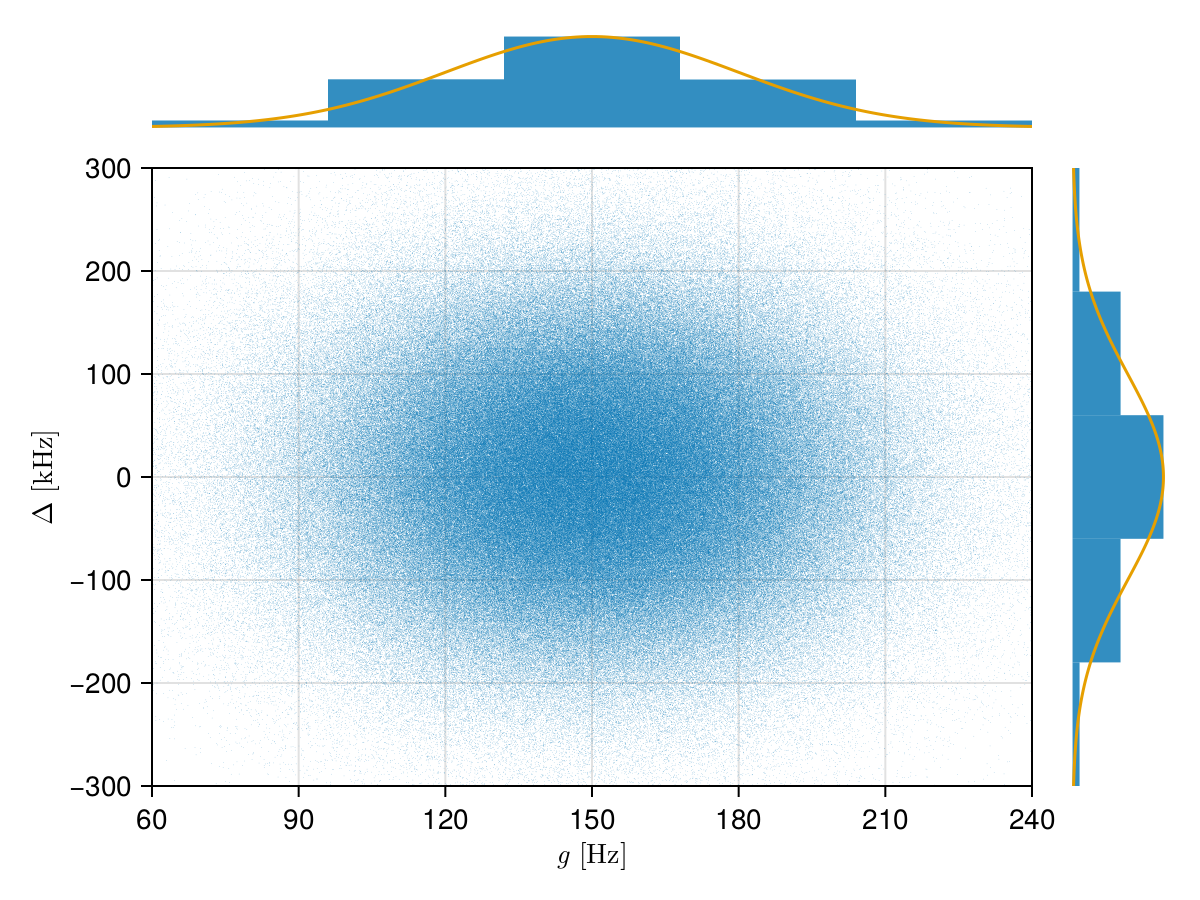

In [32]:
function make_hist_dist_samples_2D(bin_num, range_vec, g_samples, delta_samples, g0, delta_g, delta0, delta_delta)
    fig = Figure()
    # divide range_vec[1] into bin_num_bins (bin_num+1 edges)
    g_edges = range(range_vec[1][1], stop=range_vec[1][2], length=bin_num+1).*10^6
    delta_edges = range(range_vec[2][1], stop=range_vec[2][2], length=bin_num+1).*10^3
    # keep indexes in range_Vec only 
    ind = findall(x-> range_vec[1][1] .<= x .<= range_vec[1][2], g_samples)
    g_samples = g_samples[ind]
    delta_samples = delta_samples[ind]
    ind = findall(x-> range_vec[2][1] .<= x .<= range_vec[2][2], delta_samples)
    g_samples = g_samples[ind]
    delta_samples = delta_samples[ind]

    ax_top = Axis(fig[1, 1], ylabel=L"$p(g)$", height=50)
    g_values = range(range_vec[1][1], stop=range_vec[1][2], length=250)
    g_pdf = gaussian.(g_values, g0, delta_g)
    # make a histogram of g_samples 
    histogram = fit(Histogram, g_samples.*10^6, g_edges)
    hist_edges = histogram.edges[1]
    hist_weights = histogram.weights
    hist!(ax_top, g_samples.*10^6, bins=g_edges, color=Cycled(1))
    lines!(ax_top, g_values.*10^6, g_pdf./maximum(g_pdf).*maximum(hist_weights), color=Cycled(2))
    xlims!(ax_top, range_vec[1].*10^6)
    hidespines!(ax_top)
    hideydecorations!(ax_top)
    hidexdecorations!(ax_top)

    ax = Axis(fig[2, 1], xlabel=L"$g$ [Hz]", ylabel=L"$\Delta$ [kHz]")
    scatter!(ax, g_samples.*10^6, delta_samples.*10^3, markersize=0.33)
    xlims!(ax, range_vec[1].*10^6)
    ylims!(ax, range_vec[2].*10^3)



    # make x axis go from right to left 
    ax_right = Axis(fig[2, 2], xlabel=L"$p(\Delta)$", width=50)
    delta_values = range(range_vec[2][1], stop=range_vec[2][2], length=250)
    delta_pdf = gaussian.(delta_values, delta0, delta_delta)
    # make a histogram of delta_values
    histogram = fit(Histogram, delta_samples.*10^3, delta_edges)
    hist_edges = histogram.edges[1]
    hist_weights = histogram.weights
    hist!(ax_right, delta_samples.*10^3, bins=delta_edges, direction=:x, color=Cycled(1))
    lines!(ax_right, delta_pdf./maximum(delta_pdf).*maximum(hist_weights), delta_values.*10^3, color=Cycled(2))
    ylims!(ax_right, range_vec[2]*10^3)
    # flip x axis from left to right
    hidespines!(ax_right)
    hideydecorations!(ax_right)
    hidexdecorations!(ax_right)
    return fig
end
# Save the figure to Illustrations folder as spin_samples.png
bins = 5
fig = make_hist_dist_samples_2D(bins, range_vec, g_samples, delta_samples, g0, delta_g, delta0, delta_delta)
save_plot(fig, "spin_samples_$(bins)", redo=true, folder="Illustrations")

In [34]:
using Images
# load spin_samples_20.png to get size 
img = load("Illustrations/spin_samples_20.png")
x_len = size(img, 1)
y_len = size(img, 2)
bins_list = [round(Int, i) for i in 5:100]
n_frames = length(bins_list)
framestack = Array{RGB{N0f8}, 3}(undef, x_len, y_len, n_frames)
# generate image stack, create images and then save them to a video file
@threads for i in 1:n_frames
    bins = bins_list[i]
    fig = make_hist_dist_samples_2D(bins, range_vec, g_samples, delta_samples, g0, delta_g, delta0, delta_delta)
    save_plot(fig, "spin_samples_$(bins)", redo=true, folder="Illustrations/Images")
    img = load("Illustrations/Images/spin_samples_$(bins).png")
    framestack[:, :, i] = img
end

In [35]:
using VideoIO
encoder_options = (crf=0, preset="veryslow")
framerate = 30
vidname = "Illustrations/spin_samples_$(bins_list[1])_$(bins_list[end]).mp4"
open_video_out(vidname, framestack[:,:,1], framerate=framerate, codec_name = "libx264") do writer
    for i in 1:n_frames
        write(writer, framestack[:,:,i])
    end
end
println("Done")

Done


Done


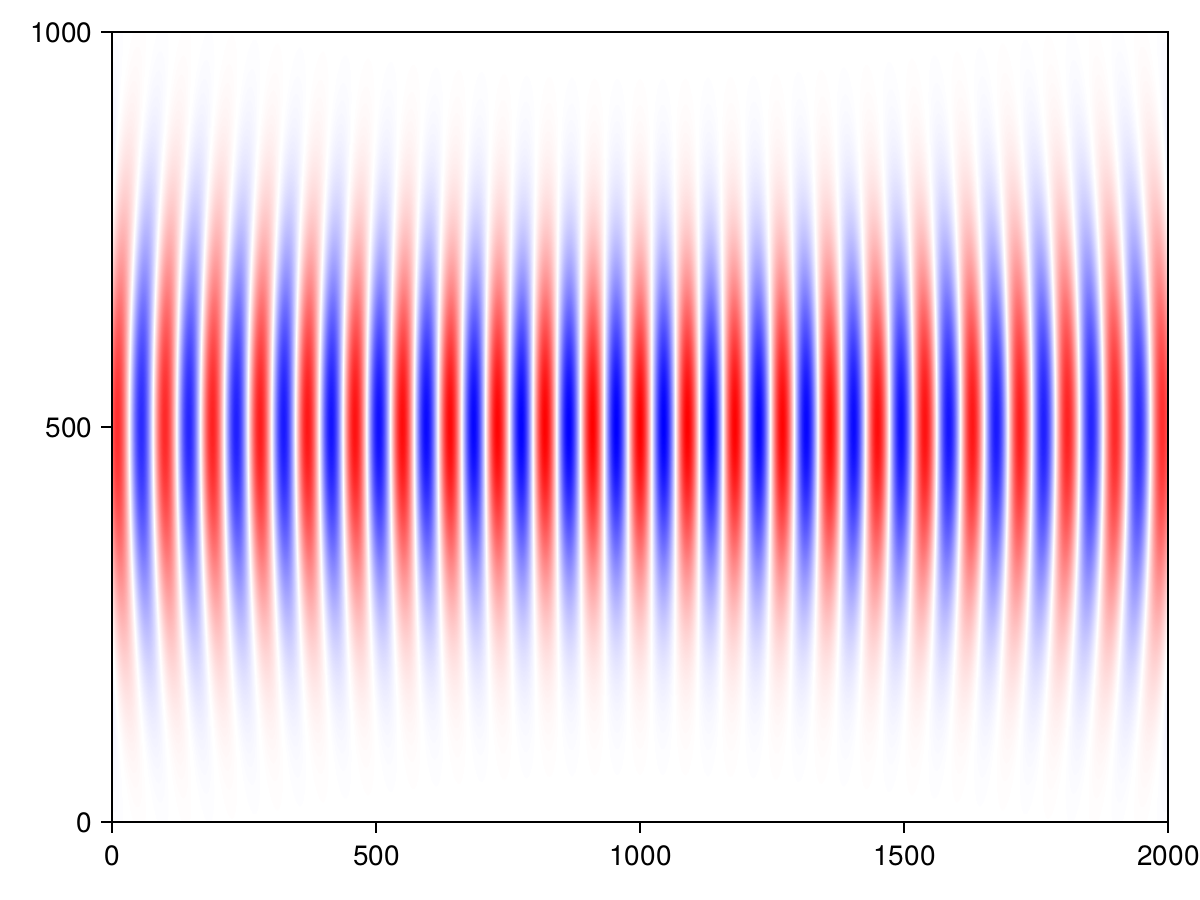

In [7]:
# A function that generates the side view of a Gauss Beam in 2D with x being the direction of travel and y being the extent of the beam orthogonal to the direction of travel
function gauss_beam_profile(z, r, w0, λ, phi=0.0)
    k = 2 * π / λ
    zR = π * w0^2 / λ
    wz = w0 * sqrt(1 + z^2 / zR^2)
    R = z*( 1 + zR^2 / z^2)
    return (w0 / wz) * exp(-r^2 / wz^2) * exp(-im * k * z - im * k * r^2 / (2 * R)- im * phi)
end
function make_z_values(z, r, w0, λ, phi=0.0)
    z = zeros(ComplexF64, length(x), length(y))
    for i in 1:length(x)
        for j in 1:length(y)
            z[i, j] = gauss_beam_profile(x[i], y[j], w0, λ, phi)
        end
    end
    return z
end

# evaluate at every point 
function make_image(x, y, w0, λ, phi)
    z = make_z_values(x, y, w0, λ, phi)
    # Create a RGB matrix (for an image) using custom_scheme and the real value of z
    realz = real.(z) .+ 1.0
    int_real_z = round.(Int, realz ./ 2.0 .* 255 .+ 1)
    color_mat = Array{RGB{N0f8}, 2}(undef, length(x), length(y))
    for i in 1:length(x)
        for j in 1:length(y)
            color_mat[i,j] = custom_scheme[int_real_z[i, j]]
        end
    end
    return color_mat
end

# make a two-dimensional grid of points to evaluate the function
x = range(-10, 10, length = 2000)
y = range(-5, 5, length = 1000)
color_mat = make_image(x, y, 2.0, 0.9, 0.0)
println("Done") # plot aspect ratio=1
image(color_mat, show_axis=false)

In [6]:
# make it an animation by adding phi from 0 to 2π
# save as .gif
# use make_image to create the frames

n_frames = 100
framestack = Array{RGB{N0f8}, 3}(undef, length(x), length(y),  n_frames)
phis = collect(range(0, 2π, length=n_frames))
@threads for i in 1:n_frames 
    curr_phi = phis[i]
    framestack[:,:,i] = make_image(x, y, 2.0, 0.9, curr_phi)
end
println("Done")

Done


In [7]:
using VideoIO
encoder_options = (crf=0, preset="veryslow")
framerate = 30
vidname = "Illustrations/gauss_beam_profile.mp4"
open_video_out(vidname, framestack[:,:,1]', framerate=framerate, codec_name = "libx264") do writer
    for i in 1:n_frames
        write(writer, framestack[:,:,i]')
    end
end
println("Done")

Done


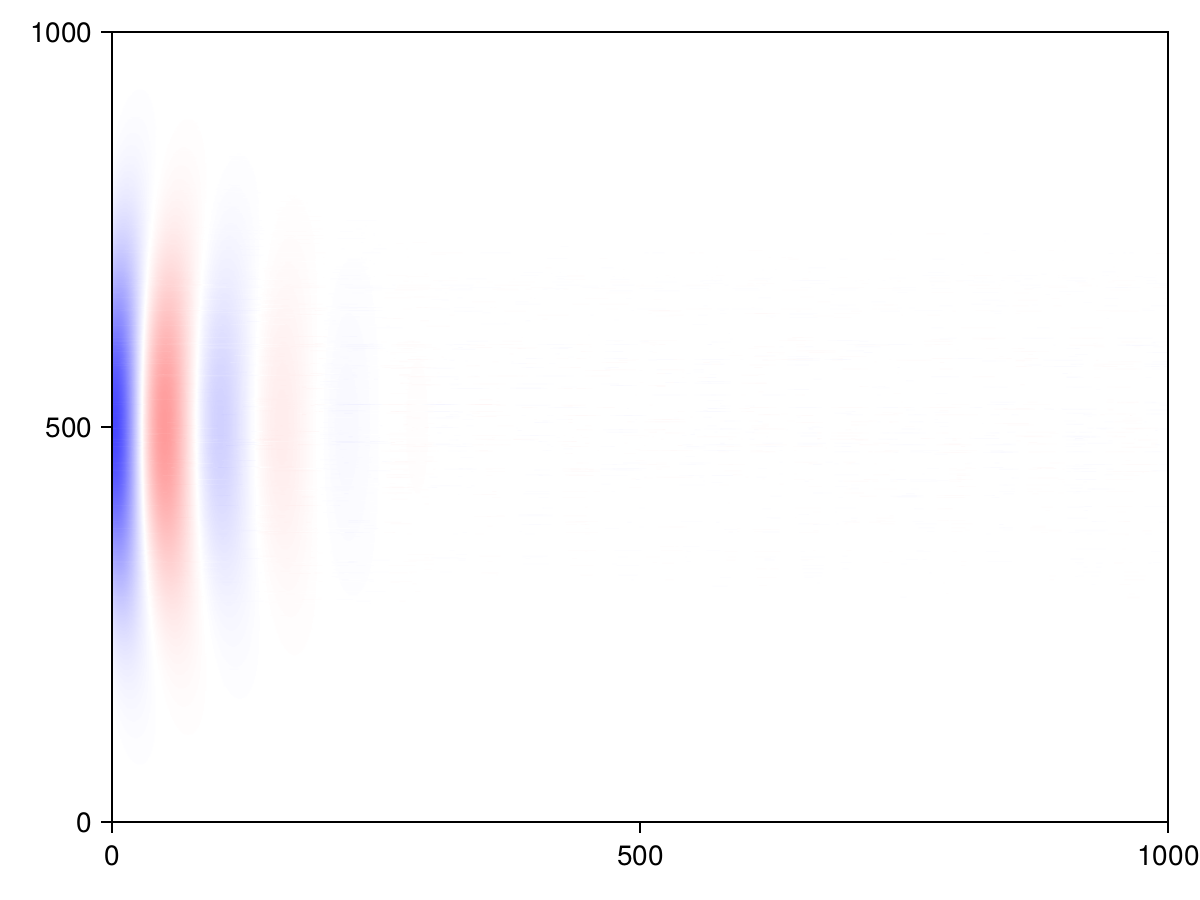

In [8]:
#### Now for a gaussian pulse
# evaluate at every point 

function make_image_gaussian(x, y, w0, λ, phi, sigma=0.2, n=10; threaded=false)
    # make gaussian superposition of different wavelengths λ_list 
    λ_list = collect(range( λ - 3*sigma, stop=λ + 3*sigma, length=n))
    amplitudes = exp.(-(λ_list.-λ).^2 ./(2*sigma^2))
    # normalize amplitudes
    amplitudes = amplitudes ./ sum(amplitudes)
    phi_i = phi ./ λ_list .* λ
    z = amplitudes[1] .* make_z_values(x, y, w0, λ_list[1], phi_i[1])
    if !threaded
        for i in 1:length(λ_list)
            z .+= amplitudes[i] .* make_z_values(x, y, w0, λ_list[i], phi_i[i])
        end
    else
        @threads for i in 1:length(λ_list)
            z .+= amplitudes[i] .* make_z_values(x, y, w0, λ_list[i], phi_i[i])
        end
    end
    # Create a RGB matrix (for an image) using custom_scheme and the real value of z
    realz = (real.(z) .+ 1.0)./ 2.0
    int_real_z = round.(Int, realz  .* 255 .+ 1)
    color_mat = Array{RGB{N0f8}, 2}(undef, length(x), length(y))
    for i in 1:length(x)
        for j in 1:length(y)
            color_mat[i,j] = custom_scheme[int_real_z[i, j]]
        end
    end
    return color_mat
end
# Test 
x = range(-5, 5, length = 1000)
y = range(-5, 5, length = 1000)
color_mat = make_image_gaussian(x, y, 2.0, 0.9, 12*pi, 0.2, 100, threaded=true)
# show the image
image(color_mat, show_axis=false)

In [9]:
# make it an animation by adding phi from 0 to 2π
# save as .gif
# use make_image to create the frames

n_frames = 100
framestack = Array{RGB{N0f8}, 3}(undef, length(x), length(y),  n_frames)
phis = collect(range(20*pi, -20*pi, length=n_frames))
for i in 1:n_frames 
    curr_phi = phis[i]
    framestack[:,:,i] = make_image_gaussian(x, y, 2.0, 0.9, curr_phi, 0.1, 100, threaded=true)
end
println("Done")

Done


In [10]:
using VideoIO
encoder_options = (crf=0, preset="veryslow")
framerate = 30
vidname = "Illustrations/gauss_beam_package.mp4"
open_video_out(vidname, framestack[:,:,1]', framerate=framerate, codec_name = "libx264") do writer
    for i in 1:n_frames
        write(writer, framestack[:,:,i]')
    end
end
println("Done")

Done


In [ ]:
function make_images_standing_wave(z, phase, custom_scheme, alpha=1.0)
    # Create a RGB matrix (for an image) using custom_scheme and the real value of z
    #epx_phase = exp.(im * phase)
    cos_phi = cos(phase)
    my_z = z .* cos_phi #epx_phase
    realz = real.(my_z) * alpha .+ 1.0
    int_real_z = round.(Int, realz ./ 2.0 .* 255 .+ 1)
    color_mat = Array{RGB{N0f8}, 2}(undef, length(x), length(y))
    for i in 1:length(x)
        for j in 1:length(y)
            color_mat[j, i] = custom_scheme[int_real_z[i, j]]
        end
    end
    return color_mat
end
# Test 
z = make_z_values(x, y, 1.2, 0.9, 0.0)

n_frames = 100
framestack = Array{RGB{N0f8}, 3}(undef, length(x), length(y),  n_frames)
phis = collect(range(0,2*pi, length=n_frames))
@threads for i in 1:n_frames 
    curr_phi = phis[i]
    framestack[:,:,i] = make_images_standing_wave(z, curr_phi, custom_scheme, 0.5)
end
println("Done")

In [ ]:
using VideoIO
encoder_options = (crf=0, preset="veryslow")
framerate = 30
vidname = "Illustrations/gauss_beam_standing_wave.mp4"
open_video_out(vidname, framestack[:,:,1], framerate=framerate, codec_name = "libx264") do writer
    for i in 1:n_frames
        write(writer, framestack[:,:,i])
    end
end
println("Done")